In [50]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.multicomp import MultiComparison


 # HLM Predictions in the Random Split

In [51]:
# We start with one concrete question:
# "Which method appeared best for HLM predictions in the Random split?"
#
# This can be changed to "Scaffold" or "Butina" later when we extend the notebook.
SPLIT_METHOD = "Random"
TARGET = "HLM"
METRIC = "mae"


In [52]:
# Random Forest summary
rf = pd.read_csv(
    "../results/hlm_mlm_cv_compare/random/rf_ecfp4/summary/rf_ecfp4_metrics_summary.csv"
)

# ChemProp summaries
cp_st_hlm = pd.read_csv(
    "../results/hlm_mlm_cv_compare/random/chemprop_single/hlm/summary/chemprop_metrics_summary.csv"
)

cp_st_fm_hlm = pd.read_csv(
    "../results/hlm_mlm_cv_compare/random/chemprop_single_foundation/hlm/summary/chemprop_metrics_summary.csv"
)

cp_mt = pd.read_csv(
    "../results/hlm_mlm_cv_compare/random/chemprop_multi/hlm_mlm/summary/chemprop_metrics_summary.csv"
)

cp_mt_fm = pd.read_csv(
    "../results/hlm_mlm_cv_compare/random/chemprop_multi_foundation/hlm_mlm/summary/chemprop_metrics_summary.csv"
)


In [53]:
# Combine all model summaries into one table
allm = pd.concat(
    [
        rf,
        cp_st_hlm,
        cp_st_fm_hlm,
        cp_mt,
        cp_mt_fm,
    ],
    ignore_index=True,
)


In [54]:
# Keep only the split / target we want to answer first
df = allm[(allm["split_method"] == SPLIT_METHOD) & (allm["target"] == TARGET)].copy()

# Each row is one fold from the 5x5 CV
df["cv_sample"] = df["cv_iter"].astype(str) + "_" + df["fold"].astype(str)


In [55]:
# Make method labels a bit cleaner for plotting / tables
method_name_map = {
    "RF_ECFP4": "RF",
    "ChemProp_ST": "ChemProp ST",
    "ChemProp_ST_FM": "ChemProp ST + FM",
    "ChemProp_MT": "ChemProp MT",
    "ChemProp_MT_FM": "ChemProp MT + FM",
}

df["method"] = df["model_family"].replace(method_name_map)


In [56]:
# Quick check of what we have
df[["method", "cv_iter", "fold", METRIC]].head()


,method,cv_iter,fold,mae
0,RF,0,0,41.344667
2,RF,0,1,38.386050
4,RF,0,2,39.522223
6,RF,0,3,37.696588
8,RF,0,4,38.228802


In [57]:
# Summary table for MAE
summary = (
    df.groupby("method", as_index=False)[METRIC]
    .agg(["count", "mean", "std", "median", "min", "max"])
    .reset_index()
    .sort_values("mean", ascending=True)
)

summary


,index,method,count,mean,std,median,min,max
3,3,ChemProp ST + FM,25,37.295835,4.617735,35.953576,30.439324,51.893485
1,1,ChemProp MT + FM,25,37.330717,3.250445,37.378065,32.885497,48.237058
4,4,RF,25,39.033495,3.010618,38.386050,33.178014,48.472274
2,2,ChemProp ST,25,43.409625,3.356128,42.566467,36.827376,49.011809
0,0,ChemProp MT,25,44.339112,2.866949,43.685827,39.815593,51.549883


In [58]:
# The method with the lowest mean MAE is the one we treat as appearing best
best_method = summary.iloc[0]["method"]
best_mae = summary.iloc[0]["mean"]

print(f"Best method by mean {METRIC.upper()} for {TARGET} on {SPLIT_METHOD}:")
print(f"{best_method} (mean {METRIC} = {best_mae:.4f})")


Best method by mean MAE for HLM on Random:
ChemProp ST + FM (mean mae = 37.2958)


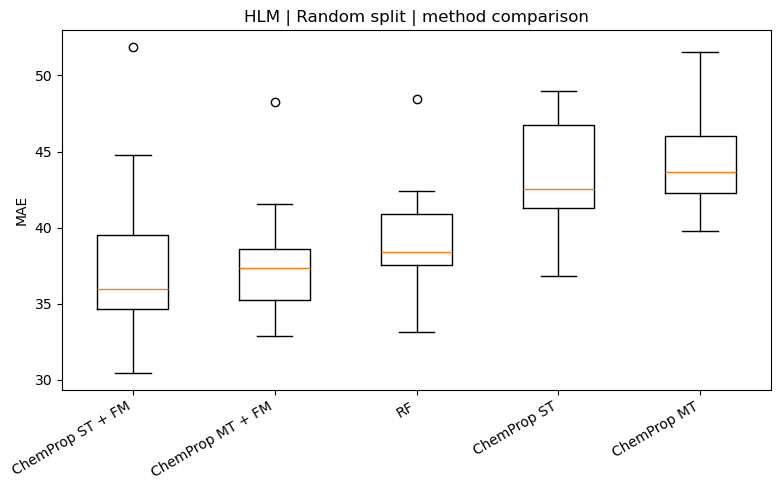

In [59]:
# Boxplot of fold-level MAE values
plot_order = summary["method"].tolist()

plot_data = [df.loc[df["method"] == method, METRIC].tolist() for method in plot_order]

plt.figure(figsize=(8, 5))
plt.boxplot(plot_data, tick_labels=plot_order)
plt.ylabel("MAE")
plt.title(f"{TARGET} | {SPLIT_METHOD} split | method comparison")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


In [60]:
# Tukey HSD on fold-level MAE values
# This is a simple first pass using the 25 fold-level values per method.
mc = MultiComparison(df[METRIC], df["method"])
tukey = mc.tukeyhsd()

print(tukey)


          Multiple Comparison of Means - Tukey HSD, FWER=0.05           
     group1           group2      meandiff p-adj   lower   upper  reject
------------------------------------------------------------------------
     ChemProp MT ChemProp MT + FM  -7.0084    0.0  -9.732 -4.2848   True
     ChemProp MT      ChemProp ST  -0.9295 0.8786 -3.6531  1.7941  False
     ChemProp MT ChemProp ST + FM  -7.0433    0.0 -9.7668 -4.3197   True
     ChemProp MT               RF  -5.3056    0.0 -8.0292  -2.582   True
ChemProp MT + FM      ChemProp ST   6.0789    0.0  3.3553  8.8025   True
ChemProp MT + FM ChemProp ST + FM  -0.0349    1.0 -2.7585  2.6887  False
ChemProp MT + FM               RF   1.7028 0.4187 -1.0208  4.4263  False
     ChemProp ST ChemProp ST + FM  -6.1138    0.0 -8.8374 -3.3902   True
     ChemProp ST               RF  -4.3761 0.0002 -7.0997 -1.6526   True
ChemProp ST + FM               RF   1.7377 0.3976 -0.9859  4.4612  False
---------------------------------------------------

In [61]:
# Turn Tukey results into a dataframe for easier viewing later
tukey_df = pd.DataFrame(
    tukey._results_table.data[1:],
    columns=tukey._results_table.data[0],
)

tukey_df = tukey_df.sort_values(
    ["reject", "p-adj"],
    ascending=[False, True],
).reset_index(drop=True)

tukey_df


,group1,group2,meandiff,p-adj,lower,upper,reject
0,ChemProp MT,ChemProp MT + FM,-7.0084,0.0000,-9.7320,-4.2848,True
1,ChemProp MT,ChemProp ST + FM,-7.0433,0.0000,-9.7668,-4.3197,True
2,ChemProp MT,RF,-5.3056,0.0000,-8.0292,-2.5820,True
3,ChemProp MT + FM,ChemProp ST,6.0789,0.0000,3.3553,8.8025,True
4,ChemProp ST,ChemProp ST + FM,-6.1138,0.0000,-8.8374,-3.3902,True
5,ChemProp ST,RF,-4.3761,0.0002,-7.0997,-1.6526,True
6,ChemProp ST + FM,RF,1.7377,0.3976,-0.9859,4.4612,False
7,ChemProp MT + FM,RF,1.7028,0.4187,-1.0208,4.4263,False
8,ChemProp MT,ChemProp ST,-0.9295,0.8786,-3.6531,1.7941,False
9,ChemProp MT + FM,ChemProp ST + FM,-0.0349,1.0000,-2.7585,2.6887,False


In [62]:
# Pull out the MAE means again in a compact table for interpretation
mean_table = (
    df.groupby("method", as_index=False)[METRIC]
    .mean()
    .rename(columns={METRIC: "mean_mae"})
    .sort_values("mean_mae", ascending=True)
    .reset_index(drop=True)
)

mean_table


,method,mean_mae
0,ChemProp ST + FM,37.295835
1,ChemProp MT + FM,37.330717
2,RF,39.033495
3,ChemProp ST,43.409625
4,ChemProp MT,44.339112


Reference method for Tukey comparison:
ChemProp ST + FM (mean MAE = 37.2958)


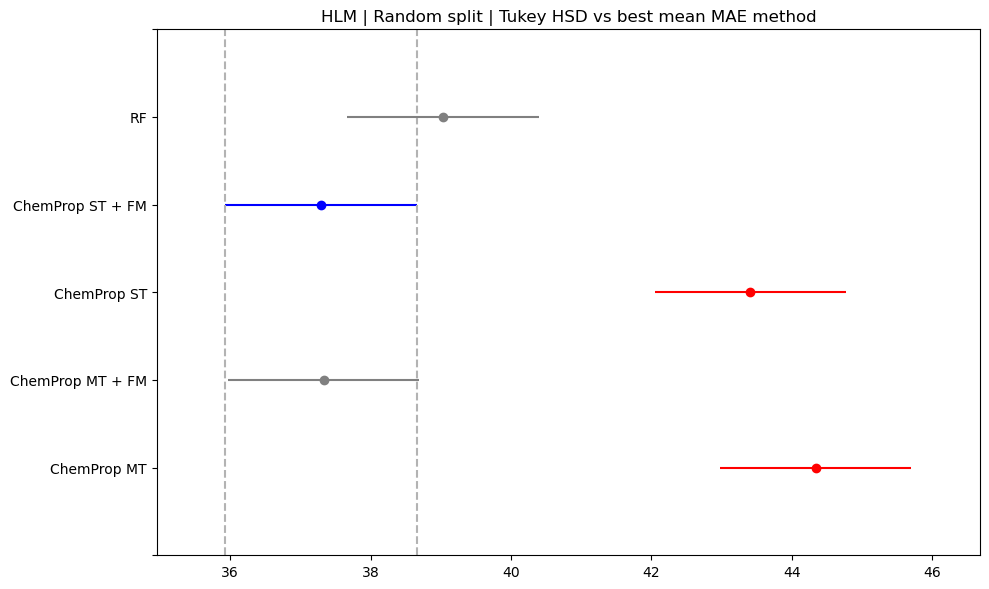

In [63]:
# We use the method with the lowest mean MAE as the reference method
best_method = mean_table.iloc[0]["method"]
best_mae = mean_table.iloc[0]["mean_mae"]

print("Reference method for Tukey comparison:")
print(f"{best_method} (mean MAE = {best_mae:.4f})")

# We'll follow the convention's of Ash et al:
tukey.plot_simultaneous(comparison_name=best_method)
plt.title(f"{TARGET} | {SPLIT_METHOD} split | Tukey HSD vs best mean MAE method")
plt.tight_layout()
plt.show()

 # MLM Predictions in the Random Split

In [64]:
# We now ask the same question for MLM predictions in the Random split.
SPLIT_METHOD = "Random"
TARGET = "MLM"
METRIC = "mae"


In [65]:
# Random Forest summary
rf = pd.read_csv(
    "../results/hlm_mlm_cv_compare/random/rf_ecfp4/summary/rf_ecfp4_metrics_summary.csv"
)

# ChemProp summaries
cp_st_mlm = pd.read_csv(
    "../results/hlm_mlm_cv_compare/random/chemprop_single/mlm/summary/chemprop_metrics_summary.csv"
)

cp_st_fm_mlm = pd.read_csv(
    "../results/hlm_mlm_cv_compare/random/chemprop_single_foundation/mlm/summary/chemprop_metrics_summary.csv"
)

cp_mt = pd.read_csv(
    "../results/hlm_mlm_cv_compare/random/chemprop_multi/hlm_mlm/summary/chemprop_metrics_summary.csv"
)

cp_mt_fm = pd.read_csv(
    "../results/hlm_mlm_cv_compare/random/chemprop_multi_foundation/hlm_mlm/summary/chemprop_metrics_summary.csv"
)


In [66]:
# Combine all model summaries into one table
allm = pd.concat(
    [
        rf,
        cp_st_mlm,
        cp_st_fm_mlm,
        cp_mt,
        cp_mt_fm,
    ],
    ignore_index=True,
)


In [67]:
# Keep only the split / target we want to answer
df = allm[(allm["split_method"] == SPLIT_METHOD) & (allm["target"] == TARGET)].copy()

# Each row is one fold from the 5x5 CV
df["cv_sample"] = df["cv_iter"].astype(str) + "_" + df["fold"].astype(str)


In [68]:
# Make method labels a bit cleaner for plotting / tables
method_name_map = {
    "RF_ECFP4": "RF",
    "ChemProp_ST": "ChemProp ST",
    "ChemProp_ST_FM": "ChemProp ST + FM",
    "ChemProp_MT": "ChemProp MT",
    "ChemProp_MT_FM": "ChemProp MT + FM",
}

df["method"] = df["model_family"].replace(method_name_map)


In [69]:
# Quick check of what we have
df[["method", "cv_iter", "fold", METRIC]].head()


,method,cv_iter,fold,mae
1,RF,0,0,401.931907
3,RF,0,1,438.824129
5,RF,0,2,411.392210
7,RF,0,3,427.064194
9,RF,0,4,435.150007


In [70]:
# Summary table for MAE
summary = (
    df.groupby("method", as_index=False)[METRIC]
    .agg(["count", "mean", "std", "median", "min", "max"])
    .reset_index()
    .sort_values("mean", ascending=True)
)

summary


,index,method,count,mean,std,median,min,max
3,3,ChemProp ST + FM,25,416.593099,30.412480,415.527288,361.868810,494.585162
1,1,ChemProp MT + FM,25,418.248547,31.823425,418.484980,364.549528,485.617386
4,4,RF,25,420.813561,24.978996,417.536702,380.046007,475.494223
0,0,ChemProp MT,25,474.161433,27.413939,471.092724,416.441592,533.753969
2,2,ChemProp ST,25,474.778224,30.473120,473.060882,414.102226,524.558260


In [71]:
# The method with the lowest mean MAE is the one we treat as appearing best
best_method = summary.iloc[0]["method"]
best_mae = summary.iloc[0]["mean"]

print(f"Best method by mean {METRIC.upper()} for {TARGET} on {SPLIT_METHOD}:")
print(f"{best_method} (mean {METRIC} = {best_mae:.4f})")


Best method by mean MAE for MLM on Random:
ChemProp ST + FM (mean mae = 416.5931)


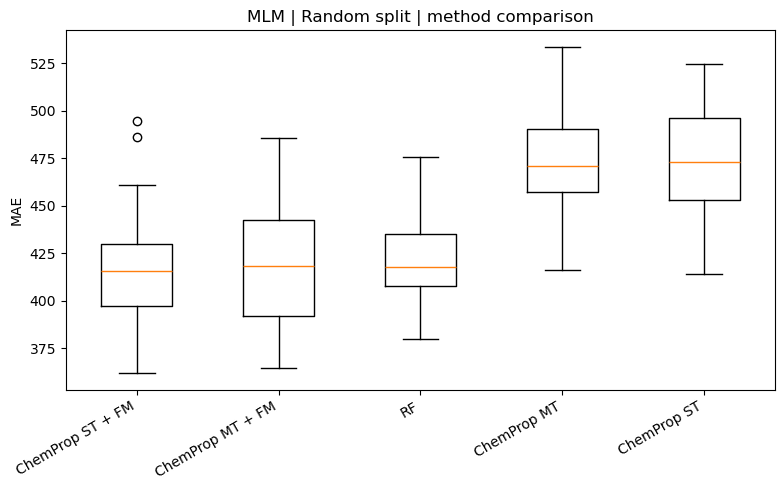

In [72]:
# Boxplot of fold-level MAE values
plot_order = summary["method"].tolist()

plot_data = [df.loc[df["method"] == method, METRIC].tolist() for method in plot_order]

plt.figure(figsize=(8, 5))
plt.boxplot(plot_data, tick_labels=plot_order)
plt.ylabel("MAE")
plt.title(f"{TARGET} | {SPLIT_METHOD} split | method comparison")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


In [73]:
# Tukey HSD on fold-level MAE values
# This is a simple first pass using the 25 fold-level values per method.
mc = MultiComparison(df[METRIC], df["method"])
tukey = mc.tukeyhsd()

print(tukey)


           Multiple Comparison of Means - Tukey HSD, FWER=0.05            
     group1           group2      meandiff p-adj   lower    upper   reject
--------------------------------------------------------------------------
     ChemProp MT ChemProp MT + FM -55.9129    0.0 -78.7301 -33.0956   True
     ChemProp MT      ChemProp ST   0.6168    1.0 -22.2005   23.434  False
     ChemProp MT ChemProp ST + FM -57.5683    0.0 -80.3856 -34.7511   True
     ChemProp MT               RF -53.3479    0.0 -76.1651 -30.5306   True
ChemProp MT + FM      ChemProp ST  56.5297    0.0  33.7124  79.3469   True
ChemProp MT + FM ChemProp ST + FM  -1.6554 0.9996 -24.4727  21.1618  False
ChemProp MT + FM               RF    2.565 0.9979 -20.2522  25.3823  False
     ChemProp ST ChemProp ST + FM -58.1851    0.0 -81.0024 -35.3679   True
     ChemProp ST               RF -53.9647    0.0 -76.7819 -31.1474   True
ChemProp ST + FM               RF   4.2205  0.986 -18.5968  27.0377  False
-------------------------

In [74]:
# Turn Tukey results into a dataframe for easier viewing later
tukey_df = pd.DataFrame(
    tukey._results_table.data[1:],
    columns=tukey._results_table.data[0],
)

tukey_df = tukey_df.sort_values(
    ["reject", "p-adj"],
    ascending=[False, True],
).reset_index(drop=True)

tukey_df


,group1,group2,meandiff,p-adj,lower,upper,reject
0,ChemProp MT,ChemProp MT + FM,-55.9129,0.0000,-78.7301,-33.0956,True
1,ChemProp MT,ChemProp ST + FM,-57.5683,0.0000,-80.3856,-34.7511,True
2,ChemProp MT,RF,-53.3479,0.0000,-76.1651,-30.5306,True
3,ChemProp MT + FM,ChemProp ST,56.5297,0.0000,33.7124,79.3469,True
4,ChemProp ST,ChemProp ST + FM,-58.1851,0.0000,-81.0024,-35.3679,True
5,ChemProp ST,RF,-53.9647,0.0000,-76.7819,-31.1474,True
6,ChemProp ST + FM,RF,4.2205,0.9860,-18.5968,27.0377,False
7,ChemProp MT + FM,RF,2.5650,0.9979,-20.2522,25.3823,False
8,ChemProp MT + FM,ChemProp ST + FM,-1.6554,0.9996,-24.4727,21.1618,False
9,ChemProp MT,ChemProp ST,0.6168,1.0000,-22.2005,23.4340,False


In [75]:
# Pull out the MAE means again in a compact table for interpretation
mean_table = (
    df.groupby("method", as_index=False)[METRIC]
    .mean()
    .rename(columns={METRIC: "mean_mae"})
    .sort_values("mean_mae", ascending=True)
    .reset_index(drop=True)
)

mean_table


,method,mean_mae
0,ChemProp ST + FM,416.593099
1,ChemProp MT + FM,418.248547
2,RF,420.813561
3,ChemProp MT,474.161433
4,ChemProp ST,474.778224


Reference method for Tukey comparison:
ChemProp ST + FM (mean MAE = 416.5931)


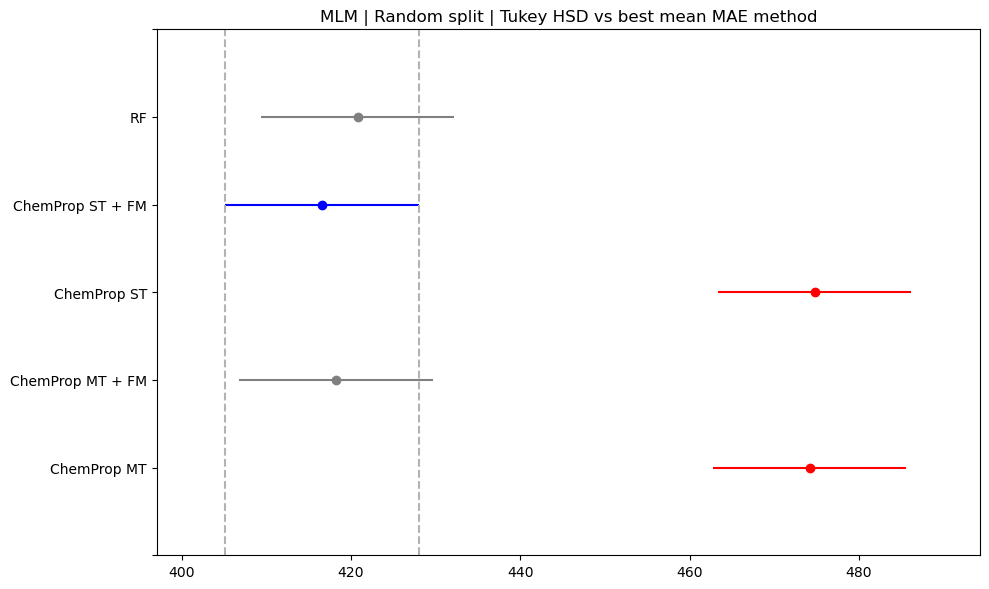

In [76]:
# We use the method with the lowest mean MAE as the reference method
best_method = mean_table.iloc[0]["method"]
best_mae = mean_table.iloc[0]["mean_mae"]

print("Reference method for Tukey comparison:")
print(f"{best_method} (mean MAE = {best_mae:.4f})")

# We'll follow the convention's of Ash et al:
tukey.plot_simultaneous(comparison_name=best_method)
plt.title(f"{TARGET} | {SPLIT_METHOD} split | Tukey HSD vs best mean MAE method")
plt.tight_layout()
plt.show()
